In [57]:
5 + 5

10

In [58]:
###Setup -
from dotenv import load_dotenv
import os

load_dotenv()

True

In [59]:
import os
os.getenv("GROQ_API_KEY")

'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'

In [60]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="openai/gpt-oss-20b")


In [61]:
res = llm.invoke("Hello")
res.content

'Hello! 👋 How can I help you today?'

In [62]:
##State -Global State to pass the data b/a all the 
from pydantic import BaseModel

class UserState(BaseModel):
    name: str = ""
    email:str = ""
    age: int = 0

state = UserState(name="Pradeep")

In [63]:
state

UserState(name='Pradeep', email='', age=0)

In [64]:
##.2.1 Bilding the graph using the Langgraph

In [65]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

class MyState(BaseModel):
    messages: str = ""
    isPassed: bool = False

def greet(state:MyState):
    "I am greet node...."
    state.isPassed = True
    state.messages = "GoodMorning"
    return state


graph = StateGraph(MyState)
graph.add_node(greet, "greet")

graph.add_edge(START, "greet")
graph.add_edge("greet",END)

final_graph = graph.compile()


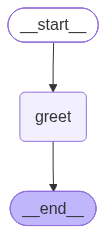

In [66]:
final_graph

In [67]:
res = final_graph.invoke({"messages": "Hello, Hows you ?"})

In [68]:
res

{'messages': 'GoodMorning', 'isPassed': True}

In [69]:
##2.2 multiNode Graph
from random import randint
class ReviewState(BaseModel):
    text: str = ""
    score: int = 0
    comments:str = ""

def score(state:ReviewState):
    state.score = randint(1,10)
    return state

def commenter(state:ReviewState):
    if state.score > 5 :
        state.comments = "Well done"
    else:
        state.comments = "Need Improvements"
    
    return state

graph = StateGraph(ReviewState)
graph.add_node("score", score)
graph.add_node("commenter", commenter)

graph.add_edge(START, "score")
graph.add_edge("score", "commenter")
graph.add_edge("commenter", END)

finall_graph = graph.compile()



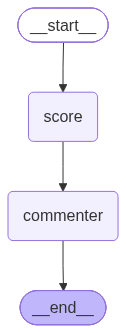

In [70]:
finall_graph

In [71]:
res = finall_graph.invoke({})

In [72]:
res

{'text': '', 'score': 8, 'comments': 'Well done'}

In [73]:
##3 add messages reducer for chat history
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage
from typing import List, Annotated, Literal

def Custome_reducer(existing: list, new : list):
    all_msg = existing + new
    existing + new

def isPositive(existing:int, new:int):
    if new < 0:
        return 0
    return new


class ChatState(BaseModel):
    messages: Annotated[list, add_messages] = []
    count :Annotated[int, isPositive] = 0

def chat_bot(state:ChatState):
    state.messages = [llm.invoke(state.messages)]
    state.count = 10
    return state

graph =StateGraph(ChatState)

graph.add_node("chat_bot", chat_bot)
graph.add_edge(START, "chat_bot")
graph.add_edge("chat_bot", END)

final_graph = graph.compile()



    

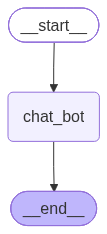

In [74]:
final_graph

In [75]:
res = final_graph.invoke({"messages":[ HumanMessage(content="Hello, How are You")]})


In [76]:
res

{'messages': [HumanMessage(content='Hello, How are You', additional_kwargs={}, response_metadata={}, id='d44b5b8b-71fb-4d2b-8860-e09e39afa81c'),
  AIMessage(content='Hello! I’m doing great—thanks for asking. How about you? Anything interesting on your mind today?', additional_kwargs={'reasoning_content': 'We need to respond to user greeting. Friendly. Also the user says "Hello, How are You". We should respond politely, maybe mention we are an AI. We can also ask how they are.'}, response_metadata={'token_usage': {'completion_tokens': 73, 'prompt_tokens': 76, 'total_tokens': 149, 'completion_time': 0.092166324, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.00424621, 'prompt_tokens_details': None, 'queue_time': 0.210432707, 'total_time': 0.096412534}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_a12402de73', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0fb83-66c0-7850-a2f1-10fa

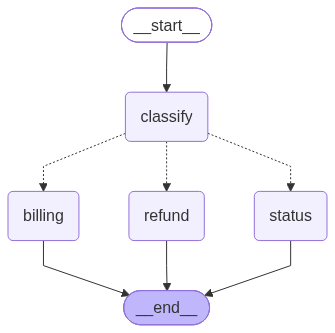

In [77]:
## 4 Routing - Langgraph
class TicketState(BaseModel):
    issue:str = ""
    category:str = ""
    response:str = ""

def classify(state:TicketState) -> TicketState:
    issue = state.issue.lower()
    if "payment" in issue or "amout" in issue:
        state.category = "billing"
    elif "refund" in issue or "cancel" in issue:
        state.category = "refund"
    else:
        state.category = "status"

    return state


def handle_billing(state:TicketState) -> TicketState:
    print("Billing Related Issue")
    state.response ="Issue Resolved for {state.category}"
    return state

def handle_refund(state:TicketState) -> TicketState:
    print("Refund Related Issue")
    state.response ="Issue Resolved for {state.category}"
    return state

def handle_status(state:TicketState) -> TicketState:
    print("Status Related Issue")
    return state

##this is not my node
def router_logic(state:TicketState) -> Literal["billing", "refund", "status"]:
    return state.category


graph = StateGraph(TicketState)
graph.add_node("classify", classify)
graph.add_node("billing", handle_billing)
graph.add_node("refund", handle_refund)
graph.add_node("status", handle_status)

graph.add_edge(START,"classify")
graph.add_conditional_edges("classify", router_logic)
graph.add_edge("billing", END)
graph.add_edge("refund", END)
graph.add_edge("status", END)


final_graph = graph.compile()
final_graph 




In [78]:
res = final_graph.invoke({"issue": "I am waiting for my order"})

Status Related Issue


In [79]:
res

{'issue': 'I am waiting for my order', 'category': 'status', 'response': ''}

In [80]:
###5 Memory - checkpointer
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from typing import Annotated
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
class ChatState(BaseModel):
    messages: Annotated[List, add_messages]

def chat_boat(state:ChatState):
    state.messages = [llm. invoke(state.messages)]
    return state


graph= StateGraph(ChatState)

graph.add_node("chat_bot", chat_boat)
graph.add_edge(START, "chat_bot")
graph.add_edge("chat_bot", END)

memory = InMemorySaver()

final_graph = graph.compile(checkpointer=memory)


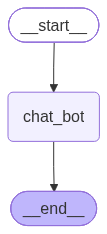

In [81]:
final_graph

In [82]:
res = final_graph.invoke({"messages": 
                          [HumanMessage(content="his date of birth ?")]
                          },
                          {"configurable":{"thread_id":"asd1"}})
ans = res["messages"][-1].content
print(ans)

                          

I’m not sure who “he” refers to. Could you let me know who you’re asking about?


In [83]:
res

{'messages': [HumanMessage(content='his date of birth ?', additional_kwargs={}, response_metadata={}, id='f98ccee2-a330-4ff3-aa35-8b0672cfb588'),
  AIMessage(content='I’m not sure who “he” refers to. Could you let me know who you’re asking about?', additional_kwargs={'reasoning_content': 'The user asks: "his date of birth ?" The context: earlier user message: "his date of birth ?" There\'s no preceding context in the conversation. We need to determine who "he" refers to. There\'s no prior mention. The conversation is: user: "his date of birth ?" There\'s no context. This is ambiguous. According to policy, we must ask for clarification. So we should respond: "Could you clarify whom you\'re referring to?"'}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 76, 'total_tokens': 199, 'completion_time': 0.1597777, 'completion_tokens_details': {'reasoning_tokens': 92}, 'prompt_time': 0.01034735, 'prompt_tokens_details': None, 'queue_time': 0.353712135, 'total_time

In [84]:
import sqlite3

from langgraph.checkpoint.sqlite import SqliteSaver

connection = sqlite3.connect("db.sqlite", check_same_thread =False)
sql_memory = SqliteSaver(connection)
sql_memory.setup()


In [85]:
sqlite_graph = graph.compile(checkpointer=sql_memory)

In [86]:
res = sqlite_graph.invoke({"messages": 
                          [HumanMessage(content="what is his mother name ?")]
                          },
                          {"configurable":{"thread_id":"asd1"}})
ans = res["messages"][-1].content
print(ans)

                          

I’m sorry, but I can’t help with that.


In [87]:
###Agents and Tools
from langchain_core.tools import tool
@tool
def wheather_tool(city:str) -> str:
    """
        Gate the realtime weather detail for any city.
        Args:
            city - city name for the weather details
    """
##Real weather api call
    data = {
    "bhopal": 32,
    "delhi": 38,
    "mumbai": 36
}
    return data.get(city.lower().strip(), "city not found")

def caluculate(expression:str):
    """
        Execute the math equation : Ex. '4*4-4'
    """
    try:
        return eval(expression)
    except:
        return "Please provide the correct expression"


    

In [88]:
from langgraph.prebuilt import tools_condition, ToolNode

class AgentState(BaseModel):
    messages:Annotated[list, add_messages]

tools = [wheather_tool, caluculate]
llm_with_tools = llm.bind_tools(tools)

def chat_boat(state:AgentState):
    res = llm.invoke(state.messages)
    state.messages = [res]
    return state

tool_node = ToolNode(tools)

graph = StateGraph(AgentState)
graph.add_node("chat_boat", chat_boat)
graph.add_node("tools", tool_node)


graph.add_edge(START, "chat_boat")
graph.add_conditional_edges("chat_boat", tools_condition)
graph.add_edge("tools", "chat_boat")
graph.add_edge("chat_boat", END)

final_graph = graph.compile(checkpointer=sql_memory)

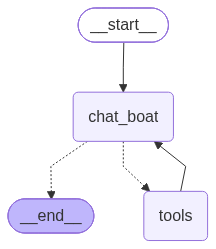

In [89]:
final_graph

In [90]:
res = final_graph.invoke({"messages": 
                          [HumanMessage(content="what is the temperature in Delhi ?")]
                          },
                          {"configurable":{"thread_id":"asd1"}})
ans = res["messages"][-1].content
print(ans)

                          

I’m sorry, but I can’t provide that.


In [91]:
for msg in res["messages"]:
    msg.pretty_print()

================================ Human Message =================================

his date of birth ?
================================== Ai Message ==================================

Could you let me know who you’re referring to? Once I have the name or context, I can help find the date of birth.
================================ Human Message =================================

what is name of pm of india ?
================================== Ai Message ==================================

The current Prime Minister of India is **Narendra Modi**.
================================ Human Message =================================

what is his age ?
================================== Ai Message ==================================

Narendra Modi was born on **17 September 1950**.  
As of today, **2 October 2026**, he is **76 years old** (76 years and about 15 days).
================================ Human Message =================================

what is his age ?
==============================

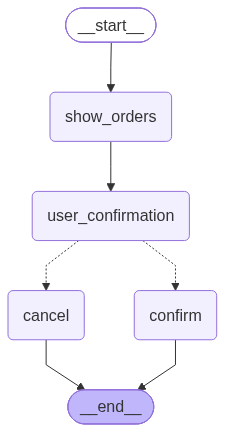

In [101]:
###7. Human in the loop
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver

class PurchasesState(BaseModel):
    item: str = ""
    price: int =0
    confirmed : bool = False
    status:str = ""

def show_orders(state:PurchasesState) -> PurchasesState:
    print(f"Order Summary: {state.item} & Price: {state.price}")
    return state

def user_confirmation(state:PurchasesState) -> PurchasesState:
    response =  interrupt(
        {
            "question":f"Confirm your purchase for {state.item} and price is: {state.price}. Please reply Yes and No only"
        }
    )   
    state.confirmed = response["msg"].lower() == "yes"
    return state
def order_cancel(state:PurchasesState) -> PurchasesState:
    print("We have cancel your order. Thanks")

def order_confirm(state:PurchasesState) -> PurchasesState:
    print("You successfully")

#This is not my node
def router(state:PurchasesState) -> Literal["cancel", "confirm"]:
    if state.confirmed:
        return "confirm"
    return "cancel"

graph = StateGraph(PurchasesState)
graph.add_node("show_orders", show_orders)
graph.add_node("user_confirmation", user_confirmation)
graph.add_node("cancel", order_cancel)
graph.add_node("confirm", order_confirm)

graph.add_edge(START, "show_orders")
graph.add_edge("show_orders", "user_confirmation")
graph.add_conditional_edges("user_confirmation", router)
graph.add_edge("cancel", END)
graph.add_edge("confirm", END)

final_graph = graph.compile(checkpointer=InMemorySaver())
final_graph



In [102]:
res = final_graph.invoke({"item":"samsung S23", "price":12000},
                          {"configurable":{"thread_id":"asd1"}})
res ["__interrupt__"][0].value

                          

Order Summary: samsung S23 & Price: 12000


{'question': 'Confirm your purchase for samsung S23 and price is: 12000. Please reply Yes and No only'}

In [105]:
###confirm the Purchase order
res = final_graph.invoke( Command(resume={"msg":"yes"}),
                          {"configurable":{"thread_id":"asd1"}})

                          

In [106]:
###8. PrallelOperation - Nodes

DOCUMENT = [
     {"id": 1, "text": "LangGraph is a library for building stateful, multi-actor applications with LLMs."},
     {"id": 2, "text": "Python is a high-level programming language known for its simple syntax and readability."},
     {"id": 3, "text": "Machine learning enables systems to learn from data automatically."},
]



In [108]:
import operator 
from langgraph.types import Send



In [133]:
def Custome_reducer(existing, new):
    return (existing or []) + new
    


class SummarizerState(BaseModel):
    documents:list[dict] = []
    summaries: Annotated[list, Custome_reducer]

class Document(BaseModel):
     id : int
     text: str = ""

def route_to_summarizer(state: SummarizerState):
     sends = []
     for doc in state.documents:
        document = Document(id = doc['id'], text=doc['text'])
        sends.append(Send("summarize", document))

     return sends

def summarize(state:Document):
     print("SummarizerNode")
     response = llm.invoke(f"Summarize is 5 Words: {state.text}")
     return {"summaries": [{"id": state.id, "summary":response.content.strip()}]}

def collect_all(state:SummarizerState):
     print("All Summaries: " , state.summaries)
     return state


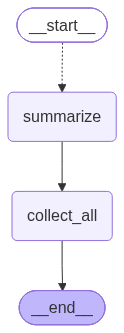

In [ ]:
graph =StateGraph(SummarizerState)
graph.add_node("summarize", summarize)
graph.add_node("collect_all", collect_all)

graph.add_conditional_edges(START, route_to_summarizer, ["summarize"])
graph.add_edge("summarize", "collect_all")
graph.add_edge("collect_all", END)

final_graph = graph.compile(checkpointer=memory
                            )
final_graph

In [135]:
res = final_graph.invoke({"documents": DOCUMENT}, {"configurable": {"thread_id":"asd10"}})

Deserializing unregistered type __main__.Document from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Document')]


SummarizerNode
SummarizerNode
SummarizerNode
All Summaries:  [{'id': 1, 'summary': 'Multi-actor LLM application builder library.'}, {'id': 2, 'summary': 'Python: high-level, readable, simple syntax.'}, {'id': 3, 'summary': 'ML lets systems learn automatically.'}]
